In [2]:
# Load cleaned data:

import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_dataset.csv"
)

df.head()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status
0,40.581311,43.627674,36.769917,127.990769,646.0,3230.0,1500.0,0.065837,82.782403,255.012964,715.803096,0
1,95.317859,39.962089,10.041088,92.399198,626.0,3130.0,243.0,0.123481,59.424540,81.204822,86.158314,0
2,74.539424,25.853852,17.985345,192.935206,101.0,303.0,229.0,0.025459,90.973363,210.685067,545.755982,0
3,61.872556,64.654000,33.500751,44.576712,52.0,156.0,1574.0,0.178884,37.344280,90.398182,541.918137,0
4,19.821771,52.896174,24.622378,117.983427,126.0,378.0,1164.0,0.167508,40.203942,87.099085,113.660688,0


In [3]:
# Feature 1 — Resource Stress Index
# CPU + Memory + Latency together indicate stress

df["resource_stress_index"] = (
    0.40 * (df["cpu_utilization"]/100)
    +
    0.35 * (df["memory_usage"]/100)
    +
    0.25 * (df["network_latency"]/200)
)

In [4]:
# Feature 2 — CPU Memory Ratio

df["cpu_memory_ratio"] = (
    df["cpu_utilization"]
    /
    (df["memory_usage"] + 1)
)

In [5]:
# Feature 3 — Disk Pressure

df["disk_pressure"] = (
    df["disk_io"]
    /
    (
        df["process_count"] + 1
    )
)

In [6]:
# Feature 4 — Context Switch Density

df["context_switch_density"] = (
    df["context_switches"]
    /
    (
        df["thread_count"] + 1
    )
)

In [7]:
# Feature 5 — Cache Efficiency

df["cache_efficiency"] = (
    1 -
    (df["cache_miss_rate"] / 100)
)

In [8]:
# Feature 6 — Thermal Stress

df["thermal_stress"] = (
    df["temperature"]
    *
    df["power_consumption"]
)

In [9]:
# Feature 7 — Uptime Category

def uptime_category(x):

    if x < 100:
        return "New"

    elif x < 1000:
        return "Stable"

    else:
        return "Long_Running"

df["uptime_category"] = (
    df["uptime"]
    .apply(uptime_category)
)

In [10]:
# Feature 8 — Resource Risk Score

df["risk_score"] = (
    0.35*(df["cpu_utilization"]/100)
    +
    0.30*(df["memory_usage"]/100)
    +
    0.20*(df["network_latency"]/200)
    +
    0.15*(df["disk_io"]/100)
)

In [11]:
# Feature 9 — Resource Risk Label

def assign_risk(score):

    if score < 0.40:
        return "Low"

    elif score < 0.70:
        return "Medium"

    else:
        return "High"

df["risk_level"] = (
    df["risk_score"]
    .apply(assign_risk)
)

In [12]:
df["risk_level"].value_counts()

risk_level
Medium    66258
Low       27342
High       6400
Name: count, dtype: int64

In [13]:
# Feature 10 — Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["risk_label"] = (
    le.fit_transform(
        df["risk_level"]
    )
)

Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

features = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress'
]

scaler = StandardScaler()

df_scaled = scaler.fit_transform(
    df[features]
)

PCA Visualization

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1","PC2"]
)

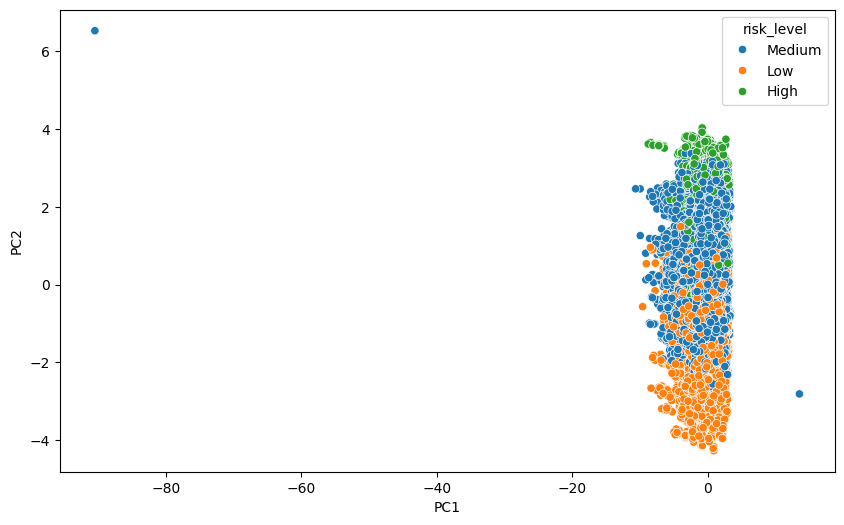

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=df["risk_level"]
)

# PCA Plot

plt.savefig(
    "../reports/figures/pca_visualization.png"
)

plt.show()

In [17]:
df.to_csv(
    "../data/processed/feature_engineered_dataset.csv",
    index=False
)

In [18]:
df["status"].value_counts()

status
0    98990
1     1010
Name: count, dtype: int64

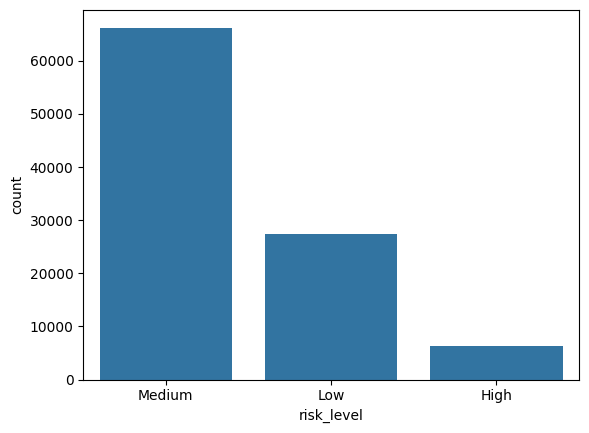

In [19]:
# Risk Distribution Plot

sns.countplot(
    data=df,
    x="risk_level"
)

plt.savefig(
    "../reports/figures/risk_distribution.png"
)

In [20]:
print(df["risk_level"].value_counts())

risk_level
Medium    66258
Low       27342
High       6400
Name: count, dtype: int64


In [21]:
df["risk_level"].value_counts()

risk_level
Medium    66258
Low       27342
High       6400
Name: count, dtype: int64

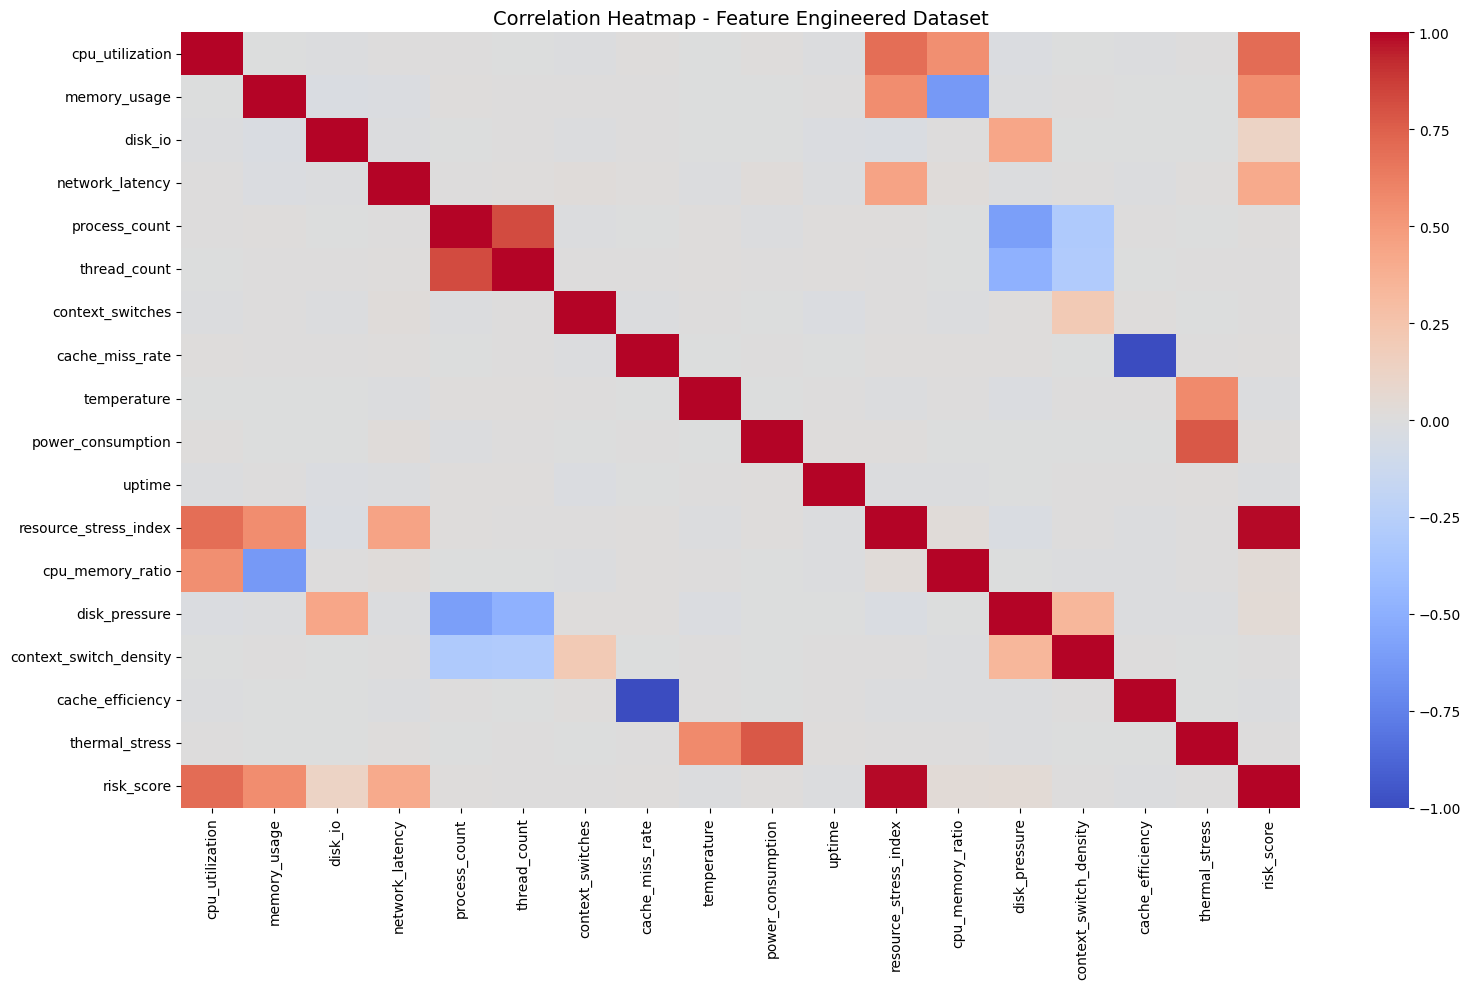

In [ ]:
# Heatmap 2 — Feature Engineered Dataset

feature_cols = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress',
    'risk_score'
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap - Feature Engineered Dataset",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap_feature_engineered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

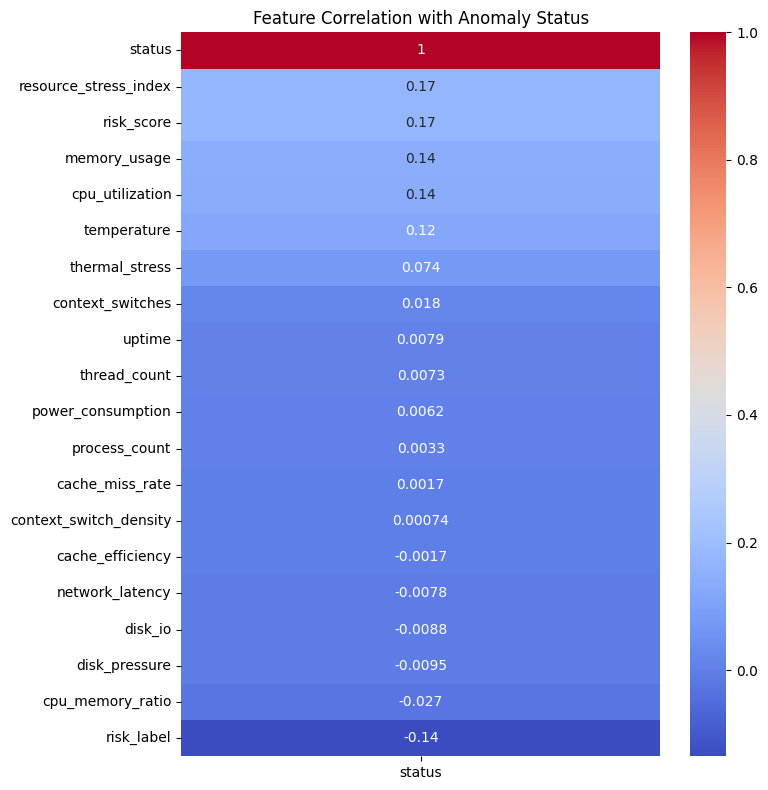

In [23]:
# Generate a heatmap showing correlation with anomaly status

status_corr = (
    df.select_dtypes(include=['number'])
      .corr()['status']
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

sns.heatmap(
    status_corr.to_frame(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation with Anomaly Status"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/status_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()